# Part 1: Driver Demographics - Exploratory Data Analysis (EDA)

## Overview
In this notebook, we initiate our project by exploring the demographic characteristics of Formula 1 drivers. Understanding the underlying distributions of age, physical attributes (height, weight), and marital status provides essential context for our dataset before diving into complex telemetry.

## Objectives
* Load and perform initial cleaning of the demographic dataset.
* Visualize the distributions of key driver attributes.
* Identify any notable patterns or underlying biases in the driver population.



### 1.1 Age Distribution
Formula 1 requires extreme physical fitness and lightning-fast reflexes. This graph illustrates the age distribution of the drivers on the grid during the 2023 season.


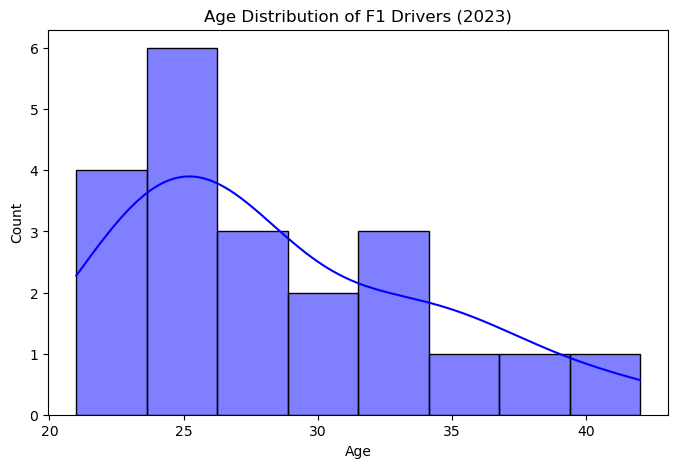

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the drivers data (adjusting path for the notebook directory)
df_drivers = pd.read_csv('../processed_data/f1_drivers_data_2023.csv')

# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_drivers['age_in_2023'], bins=8, kde=True, color='blue')
plt.title('Age Distribution of F1 Drivers (2023)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### 1.2 Physical Attributes: Height and Weight
In Formula 1, weight is a critical performance factor. Cars must meet a strict minimum weight limit, and heavier drivers can sometimes put their teams at a slight disadvantage in terms of weight distribution. Here we explore the height and weight variance across the grid.

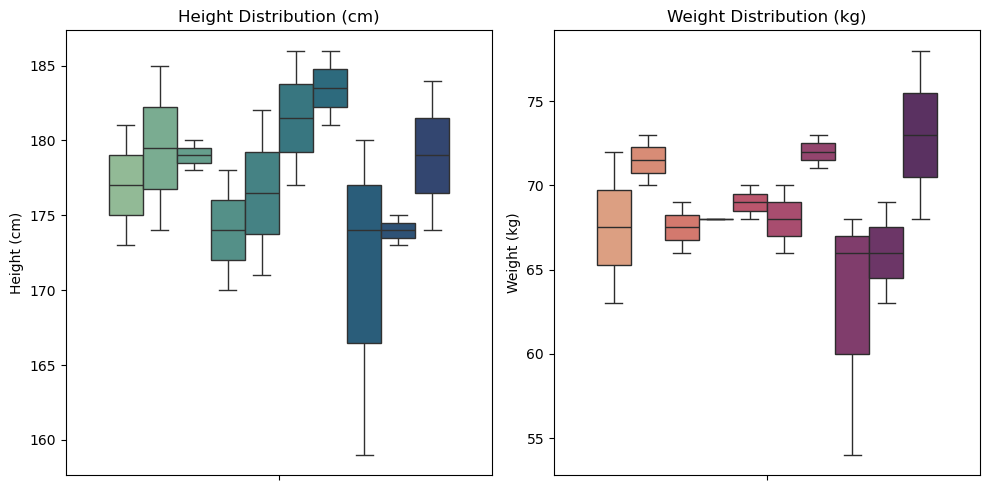

In [10]:
# Height vs Weight Boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Adding hue and legend=False to prevent seaborn warnings
sns.boxplot(data=df_drivers, y='height_cm', ax=axes[0], hue='team', legend=False, palette='crest')
axes[0].set_title('Height Distribution (cm)')
axes[0].set_ylabel('Height (cm)')

sns.boxplot(data=df_drivers, y='weight_kg', ax=axes[1], hue='team', legend=False, palette='flare')
axes[1].set_title('Weight Distribution (kg)')
axes[1].set_ylabel('Weight (kg)')

plt.tight_layout()
plt.show()

### 1.3 Personal Life: Marital Status and Children
The intense travel schedule and high-risk nature of the sport make F1 a demanding profession. The following plots provide a glimpse into the personal lives of the drivers off the track, categorizing them by relationship status and whether they have children.

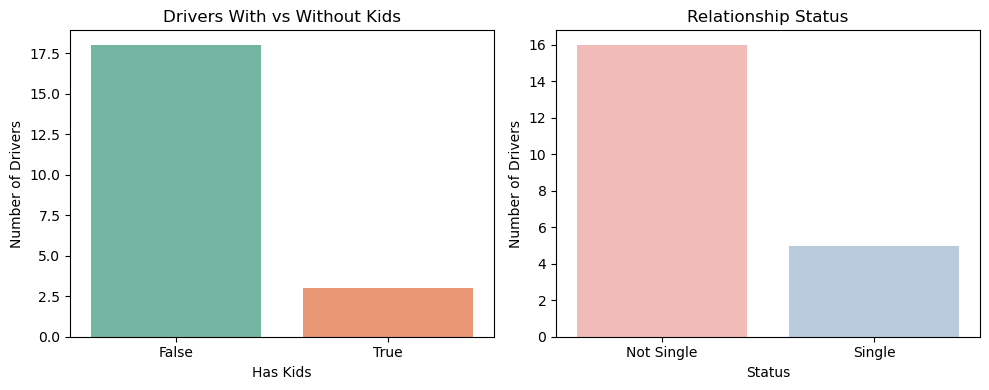

In [11]:
# Kids distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
# Using hue along with x to avoid warnings
sns.countplot(data=df_drivers, x='has_kids', hue='has_kids', palette='Set2', legend=False)
plt.title('Drivers With vs Without Kids')
plt.xlabel('Has Kids')
plt.ylabel('Number of Drivers')

# Marital status distribution
df_drivers['marital_status_clean'] = df_drivers['marital_status'].str.lower()
df_drivers['is_single'] = df_drivers['marital_status_clean'].apply(lambda x: 'Single' if x == 'single' else 'Not Single')

plt.subplot(1, 2, 2)
sns.countplot(data=df_drivers, x='is_single', hue='is_single', palette='Pastel1', legend=False)
plt.title('Relationship Status')
plt.xlabel('Status')
plt.ylabel('Number of Drivers')

plt.tight_layout()
plt.show()